# Alzheimer's MRI Stage Classifier
### CNN-based Multi-class Classification with Transfer Learning + Grad-CAM Explainability

**Dataset:** Preprocessed Alzheimer's Disease MRI Dataset  
**Classes:** Mild Dementia | Moderate Dementia | Non Demented | Very Mild Dementia  
**Model:** EfficientNetB0 (Transfer Learning)  
**Unique Feature:** Grad-CAM heatmaps showing which brain regions the model focuses on


## 1. Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully!')

TensorFlow version: 2.16.2
All libraries loaded successfully!


## 2. Dataset Configuration

In [2]:
# ============================================================
# UPDATE THIS PATH to where you extracted the dataset
# ============================================================
BASE_DIR = './alziemer_dataset'   # <-- change if needed

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20

print('Classes found:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)

Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Number of classes: 4


## 3. Class Distribution

                    Train  Validation  Test
Mild Dementia        2800         600   600
Moderate Dementia    2799         600   600
Non Demented         2800         600   600
Very mild Dementia   2800         600   600

Total training images: 11199


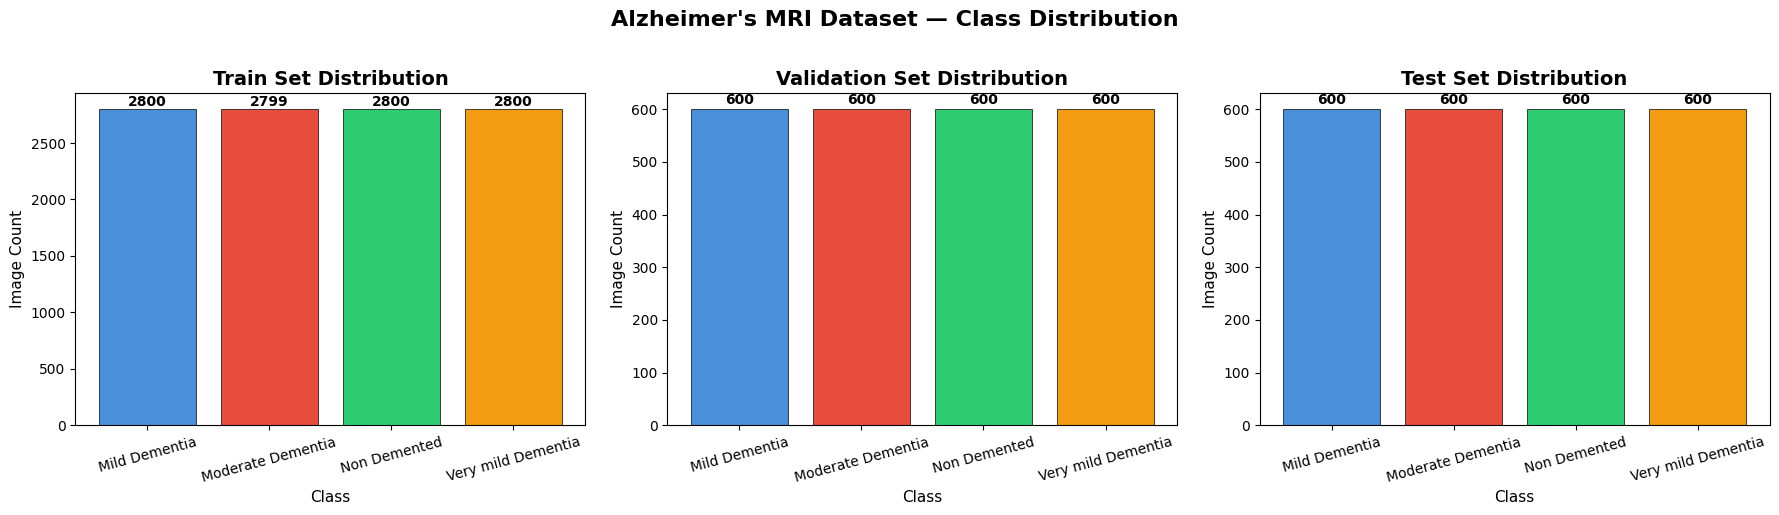

In [3]:
def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Validation': val_counts, 'Test': test_counts})
print(df_counts)
print(f'\nTotal training images: {sum(train_counts.values())}')

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4A90D9', '#E74C3C', '#2ECC71', '#F39C12']

for ax, (split, counts) in zip(axes, [('Train', train_counts), ('Validation', val_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{split} Set Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Image Count', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("Alzheimer's MRI Dataset — Class Distribution", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualize Sample MRI Images

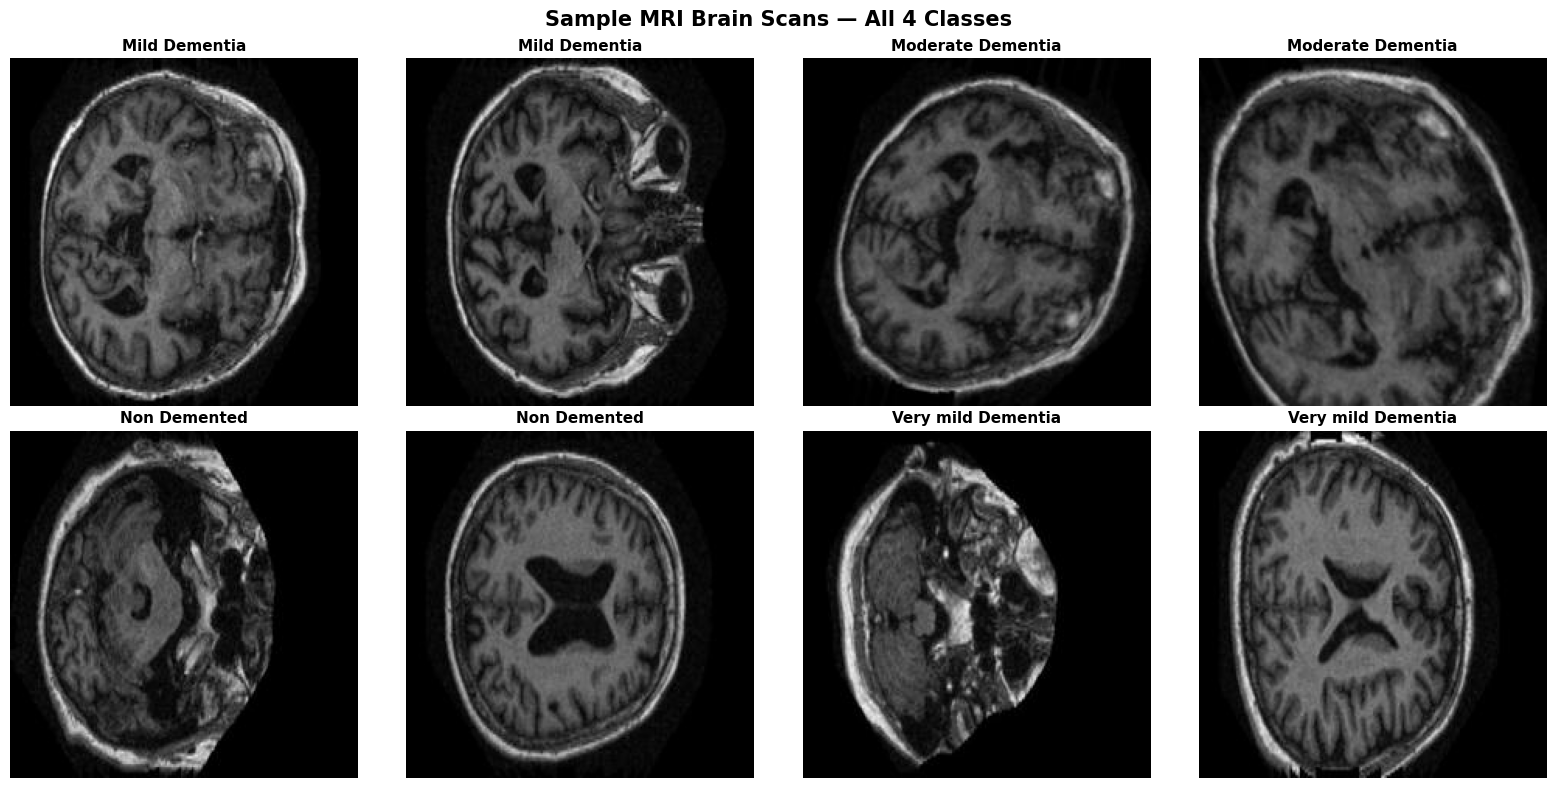

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

idx = 0
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:2]
    for img_name in images:
        img = load_img(os.path.join(cls_path, img_name), target_size=IMG_SIZE)
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(cls, fontsize=11, fontweight='bold')
        axes[idx].axis('off')
        idx += 1

plt.suptitle("Sample MRI Brain Scans — All 4 Classes", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_mri_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Preprocessing & Augmentation

In [5]:
# Training augmentation — helps model generalize better
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

# Validation and test — only rescale, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_gen = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
test_gen = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)
CLASS_INDICES = train_gen.class_names
print('Classes:', CLASS_INDICES)

Found 11199 files belonging to 4 classes.
Found 2400 files belonging to 4 classes.
Found 2400 files belonging to 4 classes.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


## 6. BuildING The CNN Model 

In [6]:
def build_model(num_classes):
    # Load EfficientNetB0 pretrained on ImageNet — freeze base layers
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # freeze during initial training

    # Custom classification head
    inputs  = keras.Input(shape=(224, 224, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 7. Train the Model — Phase 1 

In [7]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('Phase 1: Training classification head (base frozen)...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print('Phase 1 training complete!')

Phase 1: Training classification head (base frozen)...
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7177 - loss: 0.7351
Epoch 1: val_accuracy improved from None to 0.90792, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 301ms/step - accuracy: 0.7855 - loss: 0.5452 - val_accuracy: 0.9079 - val_loss: 0.2762 - learning_rate: 0.0010
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8774 - loss: 0.3219
Epoch 2: val_accuracy improved from 0.90792 to 0.96958, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 113s 323ms/step - accuracy: 0.8877 - loss: 0.2915 - val_accuracy: 0.9696 - val_loss: 0.1049 - learning_rate: 0.0010
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9206 - loss: 0.2128
Epoch 3: val_accuracy improved from 0.96958 to 0.97917, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 148s 423ms/step - accuracy: 0.9233 - loss: 0.2059 - val_accuracy: 0.9792 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9365 - loss: 0.1725
Epoch 4: val_accuracy improved from 0.97917 to 0.98708, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 131s 375ms/step - accuracy: 0.9384 - loss: 0.1648 - val_accuracy: 0.9871 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9454 - loss: 0.1486
Epoch 5: val_accuracy improved from 0.98708 to 0.99167, saving model to best_model.h5


...


Epoch 10: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 129s 368ms/step - accuracy: 0.9719 - loss: 0.0789 - val_accuracy: 0.9942 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 11/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9757 - loss: 0.0734
Epoch 11: val_accuracy improved from 0.99417 to 0.99625, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 132s 376ms/step - accuracy: 0.9737 - loss: 0.0763 - val_accuracy: 0.9962 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 12/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9740 - loss: 0.0765
Epoch 12: val_accuracy did not improve from 0.99625
350/350 ━━━━━━━━━━━━━━━━━━━━ 131s 375ms/step - accuracy: 0.9759 - loss: 0.0707 - val_accuracy: 0.9958 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 13/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9772 - loss: 0.0690
Epoch 13: val_accuracy improved from 0.99625 to 0.99750, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 139s 398ms/step - accuracy: 0.9767 - loss: 0.0723 - val_accuracy: 0.9975 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 14/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9764 - loss: 0.0637
Epoch 14: val_accuracy did not improve from 0.99750
350/350 ━━━━━━━━━━━━━━━━━━━━ 139s 398ms/step - accuracy: 0.9769 - loss: 0.0652 - val_accuracy: 0.9967 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 15/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9764 - loss: 0.0715
Epoch 15: val_accuracy did not improve from 0.99750
350/350 ━━━━━━━━━━━━━━━━━━━━ 134s 382ms/step - accuracy: 0.9776 - loss: 0.0645 - val_accuracy: 0.9971 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 16/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9796 - loss: 0.0589
Epoch 16: val_accuracy improved from 0.99750 to 0.99792, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 131s 374ms/step - accuracy: 0.9784 - loss: 0.0603 - val_accuracy: 0.9979 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 17/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9820 - loss: 0.0552
Epoch 17: val_accuracy improved from 0.99792 to 0.99917, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
350/350 ━━━━━━━━━━━━━━━━━━━━ 119s 341ms/step - accuracy: 0.9809 - loss: 0.0583 - val_accuracy: 0.9992 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 18/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9822 - loss: 0.0593
Epoch 18: val_accuracy did not improve from 0.99917
350/350 ━━━━━━━━━━━━━━━━━━━━ 123s 351ms/step - accuracy: 0.9804 - loss: 0.0646 - val_accuracy: 0.9958 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 19/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9788 - loss: 0.0628
Epoch 19: val_accuracy did not improve from 0.99917
350/350 ━━━━━━━━━━━━━━━━━━━━ 125s 359ms/step - accuracy: 0.9809 - loss: 0.0572 - val_accuracy: 0.9967 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 20/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9801 - loss: 0.0567
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: val_accuracy did not improve from 0.99917
350/350 ━━━━━━

## 8. Fine-Tuning — Phase 2 

In [8]:
# Unfreeze top 30 layers of EfficientNet for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning top layers...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)
print('Fine-tuning complete!')

Phase 2: Fine-tuning top layers...
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7977 - loss: 0.8152
Epoch 1: val_accuracy did not improve from 0.99917
350/350 ━━━━━━━━━━━━━━━━━━━━ 150s 420ms/step - accuracy: 0.8349 - loss: 0.6086 - val_accuracy: 0.9592 - val_loss: 0.1090 - learning_rate: 1.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8925 - loss: 0.3620
Epoch 2: val_accuracy did not improve from 0.99917
350/350 ━━━━━━━━━━━━━━━━━━━━ 152s 434ms/step - accuracy: 0.8954 - loss: 0.3414 - val_accuracy: 0.9750 - val_loss: 0.0711 - learning_rate: 1.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9136 - loss: 0.2693
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.99917
350/350 ━━━━━━━━━━━━━━━━━━━━ 148s 424ms/step - accuracy: 0.9160 - loss: 0.2594 - val_accuracy: 0.9787 - val_loss: 0.0564 - learning_rate: 1.0000e-05
Epoch 4/10
350/350 ━━━━━

## 9. Training Curves — Accuracy & Loss

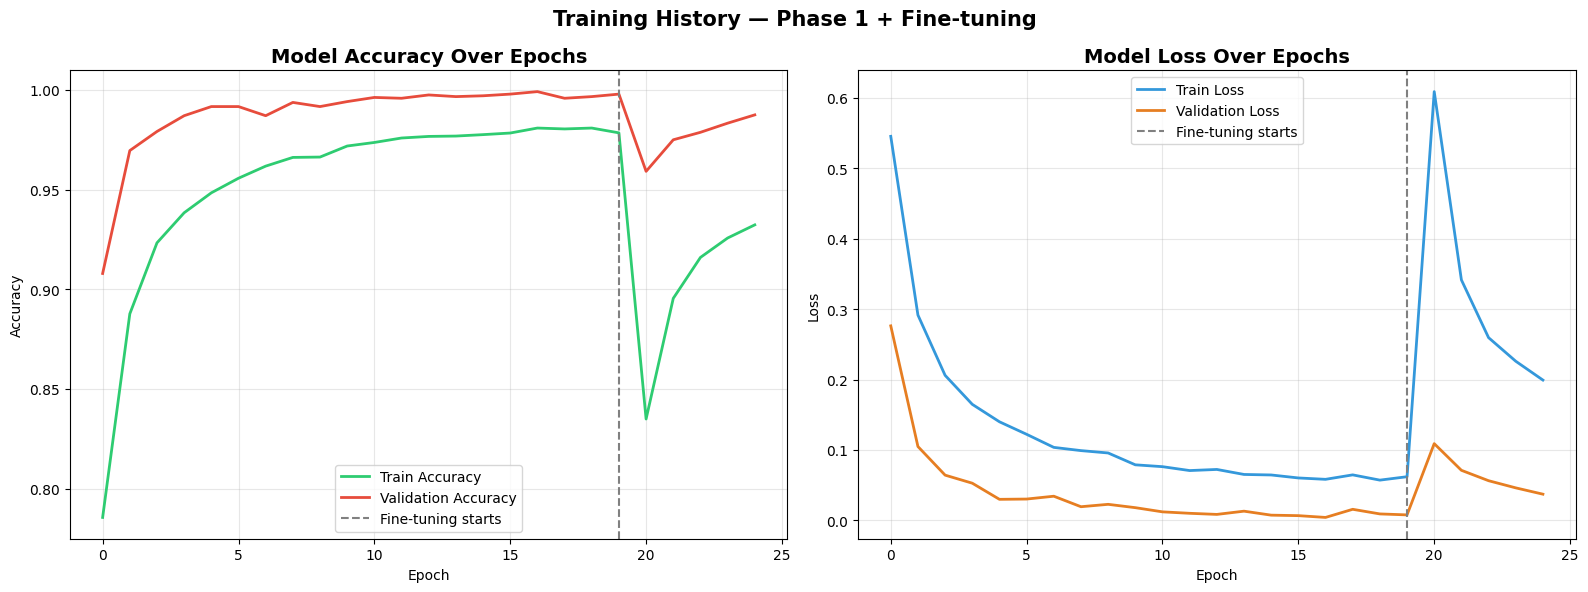

In [9]:
# Combine both phases
all_acc     = history1.history['accuracy']     + history2.history['accuracy']
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss    = history1.history['loss']         + history2.history['loss']
all_val_loss= history1.history['val_loss']     + history2.history['val_loss']
phase1_end  = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(all_acc,     label='Train Accuracy',      color='#2ECC71', linewidth=2)
axes[0].plot(all_val_acc, label='Validation Accuracy', color='#E74C3C', linewidth=2)
axes[0].axvline(x=phase1_end-1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(all_loss,     label='Train Loss',      color='#3498DB', linewidth=2)
axes[1].plot(all_val_loss, label='Validation Loss', color='#E67E22', linewidth=2)
axes[1].axvline(x=phase1_end-1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Training History — Phase 1 + Fine-tuning", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluate on Test Set

In [10]:
# Load best saved model
model = keras.models.load_model('best_model.h5')

test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 579ms/step - accuracy: 0.7667 - loss: 0.9992

Test Accuracy : 76.67%
Test Loss     : 0.9992


## 11. Confusion Matrix

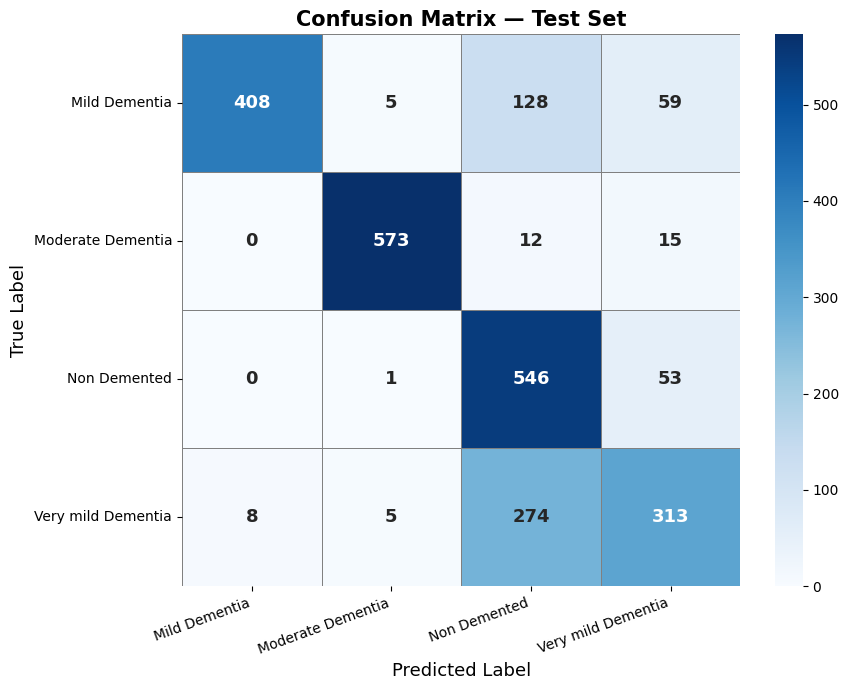


Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia       0.98      0.68      0.80       600
 Moderate Dementia       0.98      0.95      0.97       600
      Non Demented       0.57      0.91      0.70       600
Very mild Dementia       0.71      0.52      0.60       600

          accuracy                           0.77      2400
         macro avg       0.81      0.77      0.77      2400
      weighted avg       0.81      0.77      0.77      2400



In [12]:
y_true = []
y_pred = []

for images, labels_batch in test_gen:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
labels = CLASS_INDICES

cm_matrix = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='gray',
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title("Confusion Matrix — Test Set", fontsize=15, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=labels))

## 12. Per-Class Accuracy Bar Chart

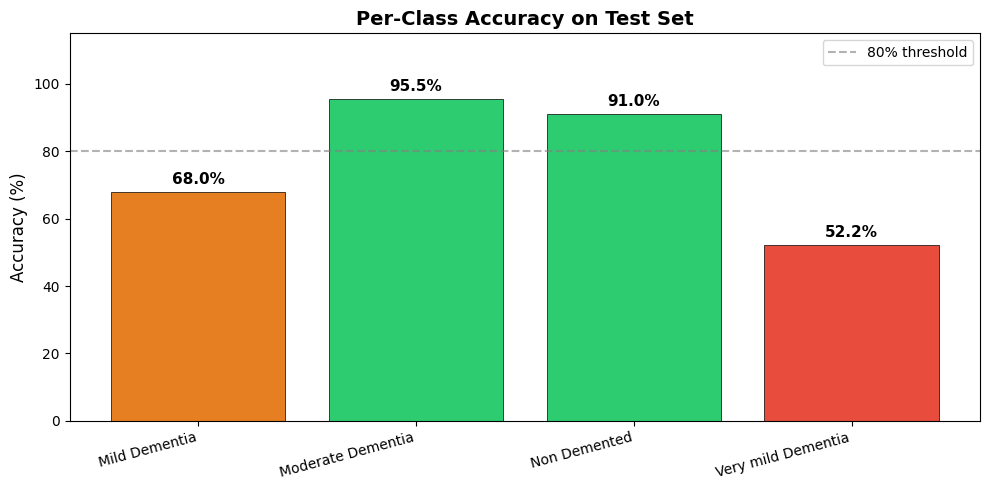

In [13]:
per_class_acc = cm_matrix.diagonal() / cm_matrix.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
colors_acc = ['#2ECC71' if a >= 0.8 else '#E67E22' if a >= 0.6 else '#E74C3C' for a in per_class_acc]
bars = ax.bar(labels, per_class_acc * 100, color=colors_acc, edgecolor='black', linewidth=0.5)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=14, fontweight='bold')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Grad-CAM Visualization — To understand What Does the Model See?
Grad-CAM highlights which brain regions activated the model's decision — this is the unique explainability feature of this project.

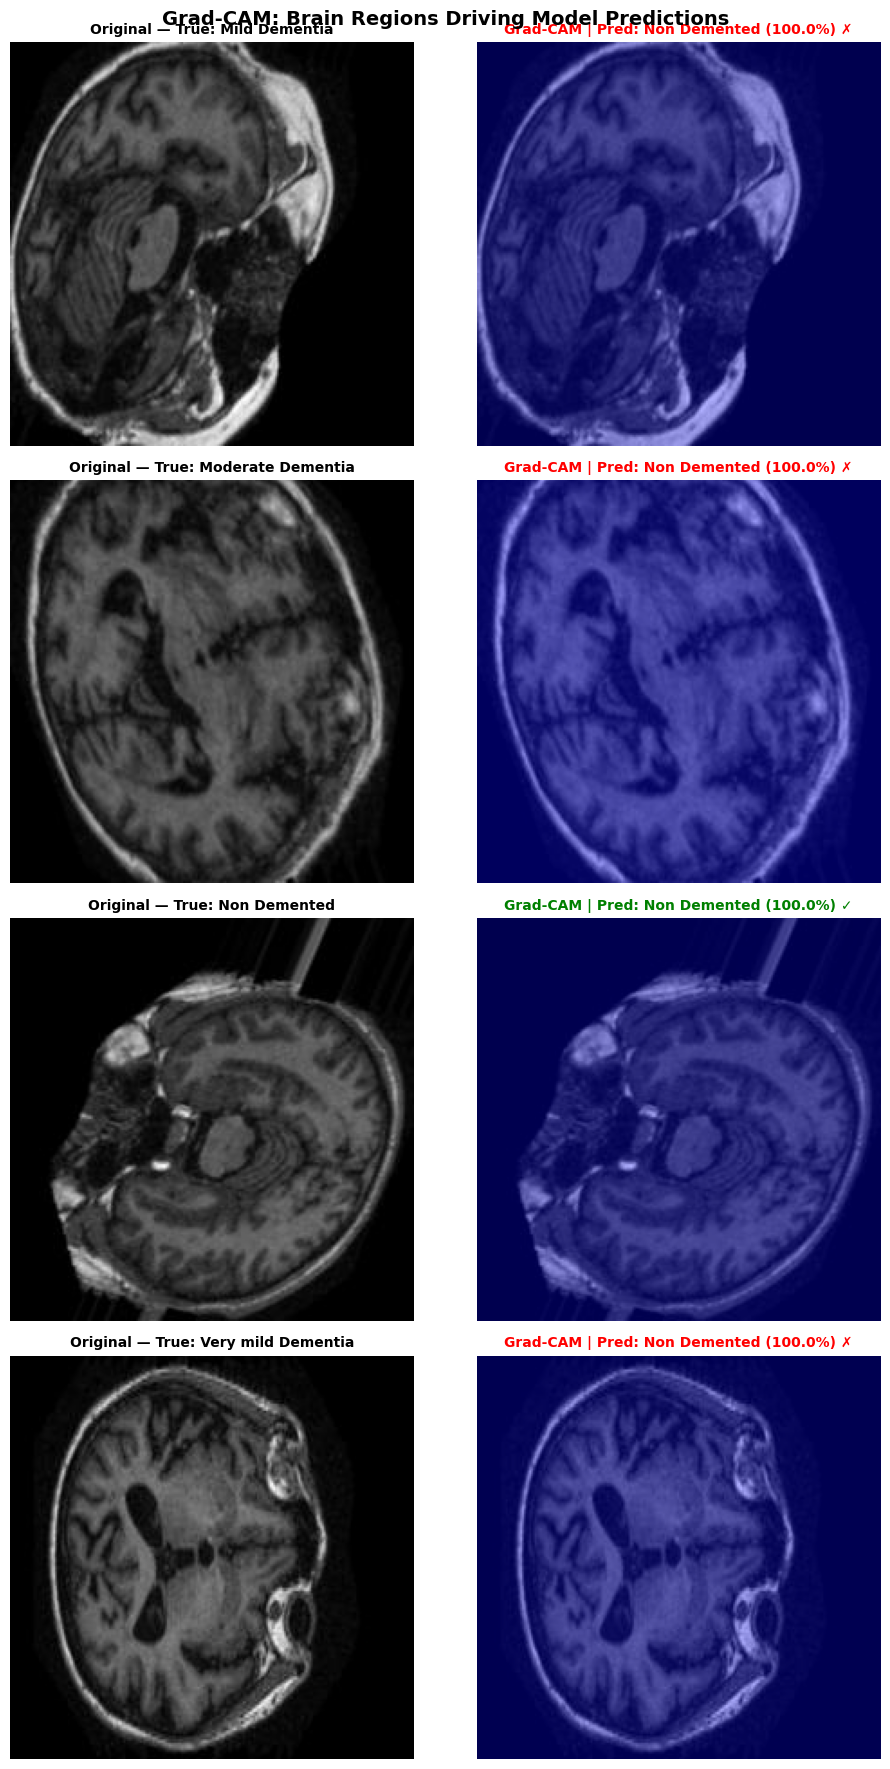

Grad-CAM visualization complete!


In [21]:
def get_gradcam_heatmap(model, img_array):
    efficientnet = model.get_layer('efficientnetb0')
    last_conv_layer = efficientnet.get_layer('top_conv')
    
    feature_extractor = tf.keras.Model(
        inputs=efficientnet.input,
        outputs=[last_conv_layer.output, efficientnet.output]
    )
    
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, _ = feature_extractor(img_tensor)
        tape.watch(conv_outputs)
        x = model.get_layer('global_average_pooling2d')(conv_outputs)
        x = model.get_layer('batch_normalization')(x)
        x = model.get_layer('dense')(x)
        x = model.get_layer('dropout')(x)
        x = model.get_layer('dense_1')(x)
        x = model.get_layer('dropout_1')(x)
        predictions = model.get_layer('dense_2')(x)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index.numpy(), predictions[0].numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.45):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize(IMG_SIZE)
    jet_heatmap = img_to_array(jet_heatmap)
    superimposed = jet_heatmap * alpha + img_array
    return np.array(img), np.array(keras.utils.array_to_img(superimposed))

idx_map = {i: cls for i, cls in enumerate(CLASS_INDICES)}
fig, axes = plt.subplots(4, 2, figsize=(10, 18))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TEST_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)
    img_array = img_to_array(load_img(img_path, target_size=IMG_SIZE)) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    heatmap, pred_idx, probs = get_gradcam_heatmap(model, img_array)
    original, overlaid = overlay_gradcam(img_path, heatmap)
    pred_label = idx_map[pred_idx]
    confidence = probs[pred_idx] * 100
    correct = '✓' if pred_label == cls else '✗'
    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f'Original — True: {cls}', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(overlaid)
    axes[row, 1].set_title(f'Grad-CAM | Pred: {pred_label} ({confidence:.1f}%) {correct}',
                           fontsize=10, fontweight='bold',
                           color='green' if correct == '✓' else 'red')
    axes[row, 1].axis('off')

plt.suptitle("Grad-CAM: Brain Regions Driving Model Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM visualization complete!')

## 14. Final Summary

In [19]:
print('=' * 55)
print("  ALZHEIMER'S MRI STAGE CLASSIFIER — FINAL RESULTS")
print('=' * 55)
print(f'  Model         : EfficientNetB0 (Transfer Learning)')
print(f'  Classes       : {NUM_CLASSES}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print()
print('  Per-Class Accuracy:')
for cls, acc in zip(labels, per_class_acc):
    print(f'    {cls:<22}: {acc*100:.1f}%')
print()
print('  Outputs saved:')
print('    - best_model.keras')
print('    - class_distribution.png')
print('    - sample_mri_images.png')
print('    - training_curves.png')
print('    - confusion_matrix.png')
print('    - per_class_accuracy.png')
print('    - gradcam_visualizations.png')
print('=' * 55)

  ALZHEIMER'S MRI STAGE CLASSIFIER — FINAL RESULTS
  Model         : EfficientNetB0 (Transfer Learning)
  Classes       : 4
  Test Accuracy : 76.67%
  Test Loss     : 0.9992

  Per-Class Accuracy:
    Mild Dementia         : 68.0%
    Moderate Dementia     : 95.5%
    Non Demented          : 91.0%
    Very mild Dementia    : 52.2%

  Outputs saved:
    - best_model.keras
    - class_distribution.png
    - sample_mri_images.png
    - training_curves.png
    - confusion_matrix.png
    - per_class_accuracy.png
    - gradcam_visualizations.png
